#1. Library Installation and Imports

##Installing Libraries

In [144]:
!pip install emoji
!pip install contractions

## Importing Libraries

In [145]:
import pandas as pd
import numpy as np
import re
import emoji
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pickle
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.corpus import opinion_lexicon
import unicodedata
import contractions
import matplotlib.pyplot as plt
import seaborn as sns
import string
from wordcloud import WordCloud, STOPWORDS
from collections import Counter
from PIL import Image
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
nltk.download('opinion_lexicon')


# Show all rows and columns
pd.set_option('display.max_rows', None)  # Show all rows
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', None)  # Adjust width to avoid truncation
pd.set_option('display.max_colwidth', None)  # Show full column content

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package opinion_lexicon to /root/nltk_data...
[nltk_data]   Package opinion_lexicon is already up-to-date!


#2. Loading Dataset and Initial Exploration

##Reading CSV into dataframe

In [146]:
df = pd.read_csv("./Sentiment_Data.csv", encoding='latin1')

Datatypes of dataset

## Displaying head and info

In [147]:
print("Head --" , df.head())
print("------------------------------------------------------------------------------------------------------------------------------------")
print("------------------------------------------------------------------------------------------------------------------------------------")
print("Info --", df.info())

Head --                                                                                                                                                                                                                                 Tweet  \
0               @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
1             @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
2  @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9   
3                 @NChartierET Happy Anniversary!!!....The D

## Shape of the dataset

In [148]:
len(df),df.index.shape[-1]

(451332, 451332)

In [149]:
print("Shape of dataset: ".format(), df.shape)

Shape of dataset:  (451332, 2)


## Extract tweets for each specific sentiment class to inspect sample data

In [150]:
mild_pos_tweet = df[df['Sentiment'] == 'Mild_Pos']['Tweet']
mild_neg_tweet = df[df['Sentiment'] == 'Mild_Neg']['Tweet']
neutral_tweet = df[df['Sentiment'] == 'Neutral']['Tweet']
strong_pos_tweet = df[df['Sentiment'] == 'Strong_Pos']['Tweet']
strong_neg_tweet = df[df['Sentiment'] == 'Strong_Neg']['Tweet']

## Group the tweets by sentiment label for easier iteration

In [151]:
sentiment_samples = {
    "Mild_Pos": mild_pos_tweet,
    "Mild_Neg": mild_neg_tweet,
    "Neutral": neutral_tweet,
    "Strong_Pos": strong_pos_tweet,
    "Strong_Neg": strong_neg_tweet
}

# 3. Exploratory Data Analysis (EDA) - Sentiment Distribution

## Print the first 5 tweets of each sentiment category to get a sense of the data

In [152]:
for label, series in sentiment_samples.items():
    print(f"\n{'='*10} First 5 samples of {label.replace('_', ' ').title()} tweets {'='*10}\n")
    for i, tweet in enumerate(series.head(5), 1):
        print(f"{i}. {tweet}\n")


========== First 5 samples of Mild Pos tweets ==========

1. @_angelica_toy Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

2. @McfarlaneGlenda Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

3. @thevivafrei @JustinTrudeau Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

4. @NChartierET Happy Anniversary!!!....The Day the FreeDUMB Died (In the tune of Don McLean's "American Pie") #FreeDumbConvoy #Freedumbers #FluTruxKlan #convoywatch #convoy #FreedomConvoy   https://t.co/ZT1cIPwmh9

5. @tabithapeters05 Happy Anniversary!!!....The Day the 

## Helper function to plot sentiment counts

In [153]:
def plot_sentiment_counts(sentiment_counts):
    plt.rcParams['figure.figsize'] = (8, 6)
    bars = plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'gray', 'darkgreen', 'darkred'])
    plt.xlabel('Sentiment Class')
    plt.ylabel('Number of Tweets')
    plt.title('Number of Tweets per Sentiment Class')

    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 500, int(yval), ha='center', va='bottom', fontsize=10)
    plt.show()

Total Counts of all sentiment classes:
 Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


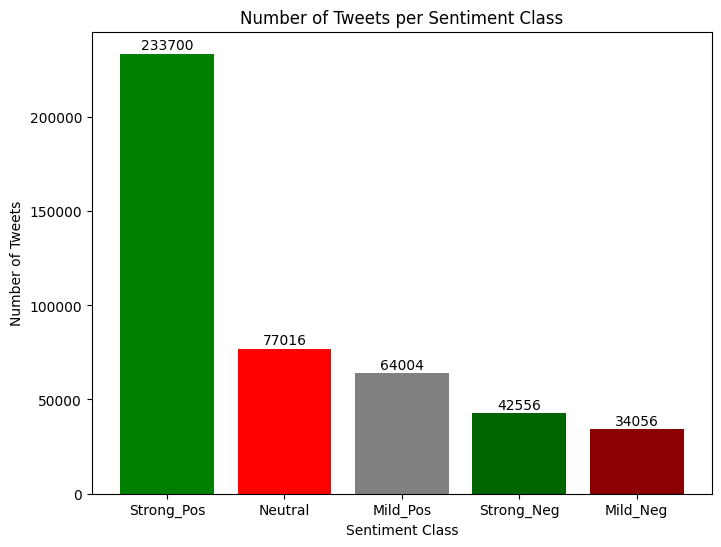

In [154]:
# Calculate the number of tweets per sentiment class
sentiment_counts = df['Sentiment'].value_counts()

print('Total Counts of all sentiment classes:\n', sentiment_counts)
print("==============")

# Plot a bar chart to visualize the distribution of tweet counts across sentiment classes
plot_sentiment_counts(sentiment_counts)

#4. Feature Extraction - Word Count and Punctuation Count

## Calculate the number of words in each tweet and store it in a new column 'word_count'

In [155]:
# Handles any non-string entries safely by assigning a count of 0
df['word_count'] = df['Tweet'].apply(lambda x: len(str(x).split()) if isinstance(x, str) else 0)

### Word count distribution plot

/tmp/ipython-input-156-2351425197.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(word_counts, bins=30, kde=True, color="skyblue", hist_kws={"alpha":0.5}, ax=axes[idx])
/tmp/ipython-input-156-2351425197.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(word_counts, bins=30, kde=True, col

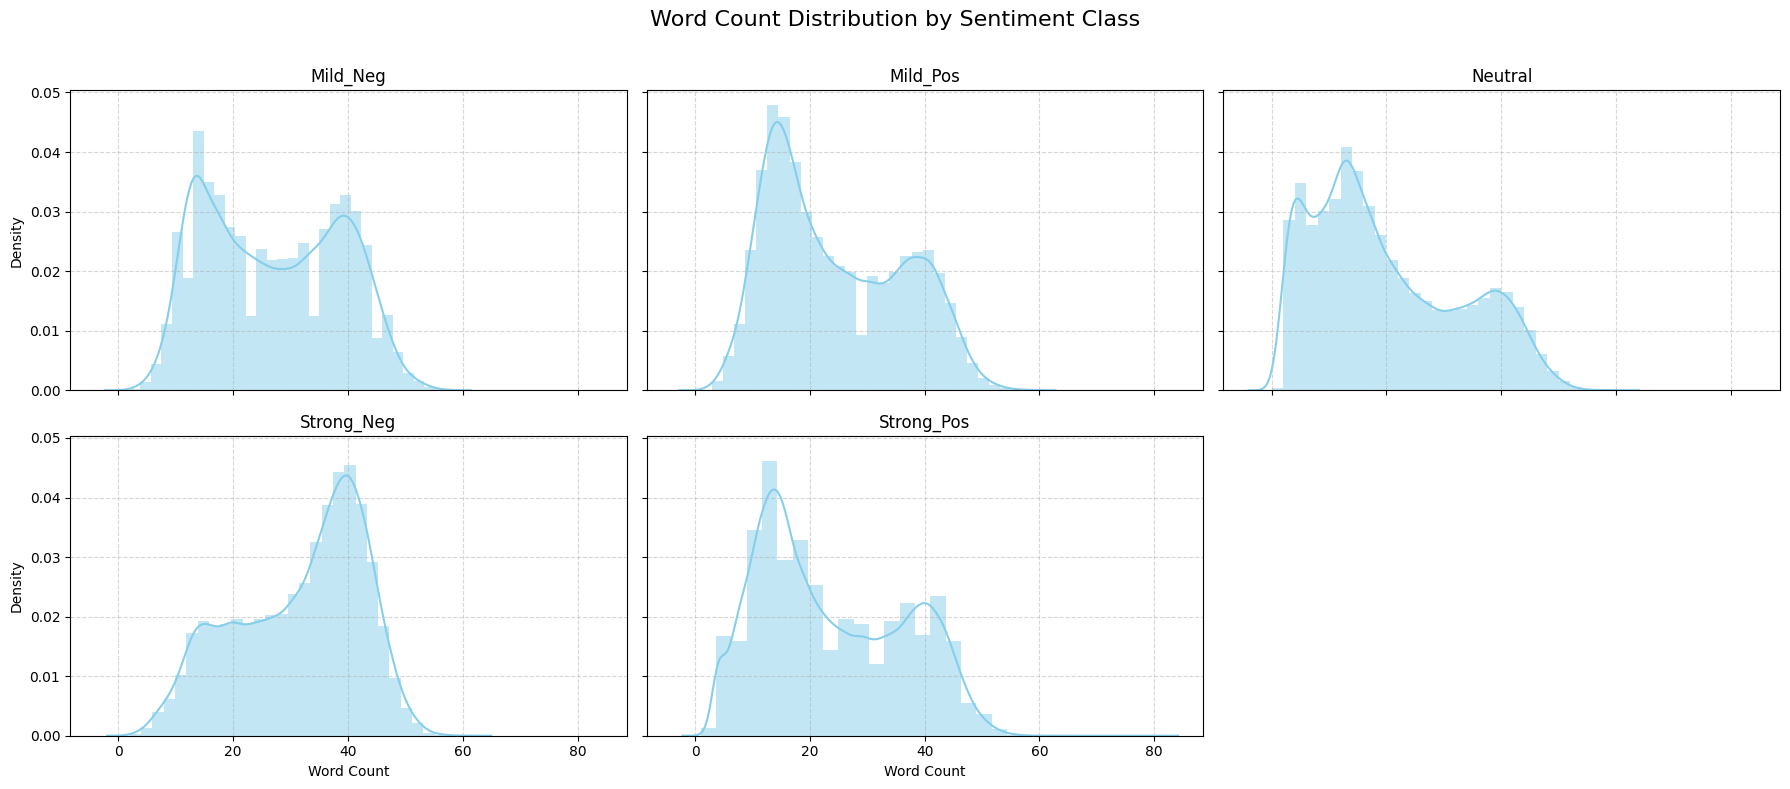

In [156]:
# Get a sorted list of unique sentiment classes in the dataset
sentiments = sorted(df['Sentiment'].unique())

# Create a 2x3 grid of subplots for plotting word count distributions per sentiment
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

# For each sentiment class, plot the distribution of word counts using a histogram + KDE
for idx, sentiment in enumerate(sentiments):
    word_counts = df[df['Sentiment'] == sentiment]['word_count']
    sns.distplot(word_counts, bins=30, kde=True, color="skyblue", hist_kws={"alpha":0.5}, ax=axes[idx])
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Word Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

# Hide any unused subplot if sentiment classes are fewer than subplot slots
if len(sentiments) < len(axes):
    for idx in range(len(sentiments), len(axes)):
        axes[idx].set_visible(False)

# Set the main title and adjust layout for the whole figure
fig.suptitle("Word Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## Adding punctuation count for each tweet in the dataframe

In [157]:
df['punctuation_count'] = df['Tweet'].apply(lambda z: len([c for c in str(z) if c in string.punctuation]))

### Punctuation count distribution plot

/tmp/ipython-input-158-787223585.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(counts, bins=20, kde=True, color="purple", hist_kws={"alpha":0.5}, ax=axes[idx])
/tmp/ipython-input-158-787223585.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(counts, bins=20, kde=True, color="purple", hi

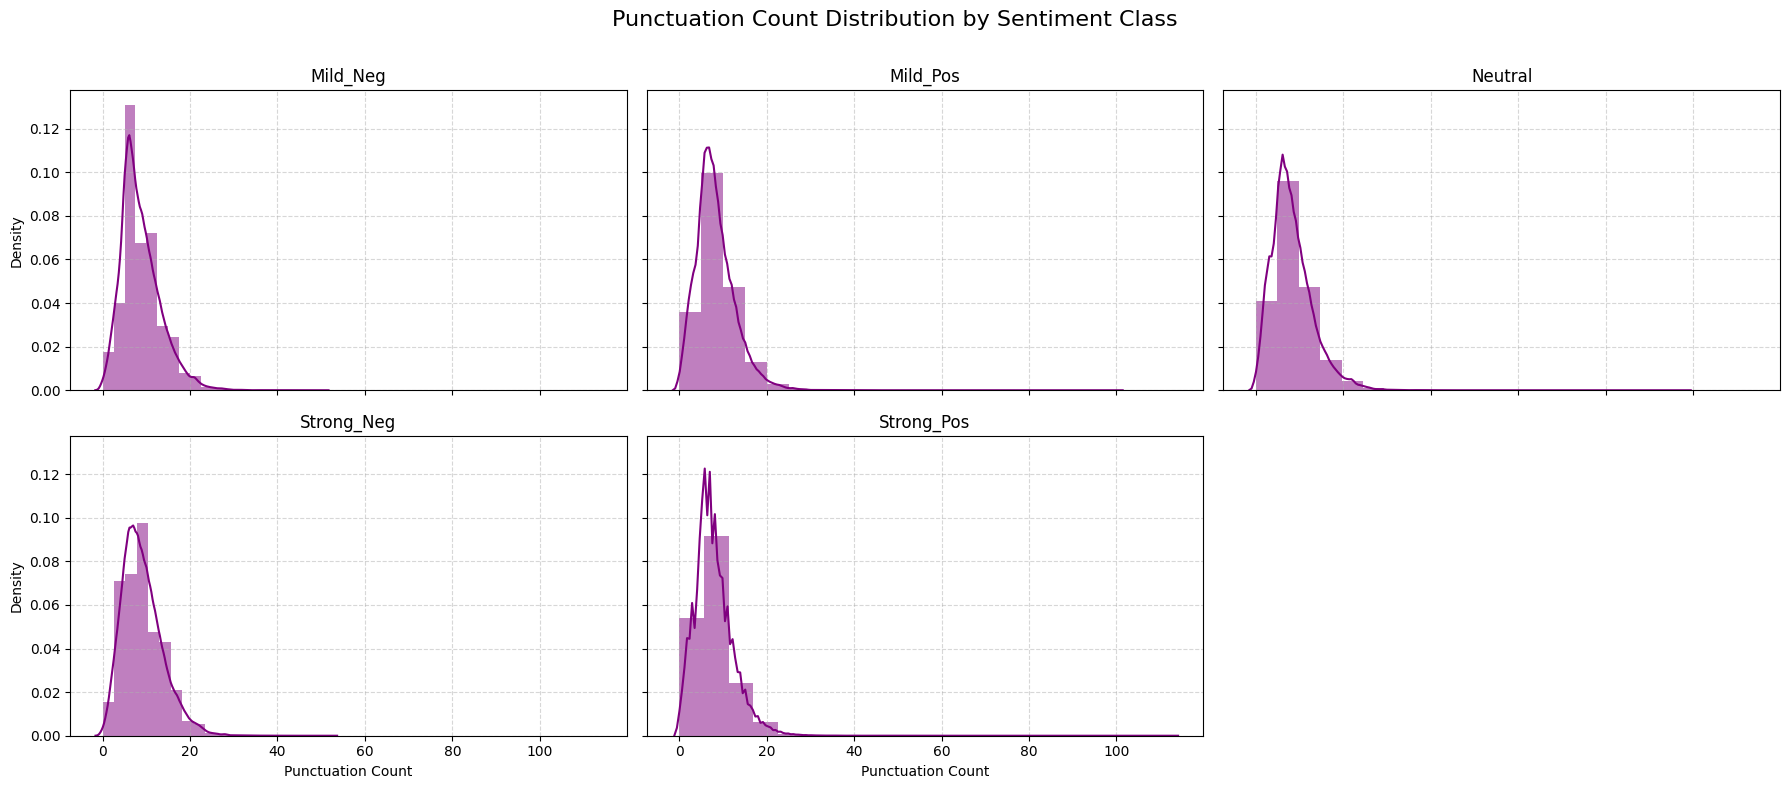

In [158]:
sentiments = sorted(df['Sentiment'].unique())
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for idx, sentiment in enumerate(sentiments):
    counts = df[df['Sentiment'] == sentiment]['punctuation_count']
    sns.distplot(counts, bins=20, kde=True, color="purple", hist_kws={"alpha":0.5}, ax=axes[idx])
    axes[idx].set_title(f"{sentiment}")
    axes[idx].set_xlabel("Punctuation Count")
    axes[idx].set_ylabel("Density")
    axes[idx].grid(True, linestyle="--", alpha=0.5)

for idx in range(len(sentiments), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Punctuation Count Distribution by Sentiment Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


#5. Handling Missing Values

## Checking for nulls

In [159]:
df.isnull().sum()

,0
Tweet,1
Sentiment,0
word_count,0
punctuation_count,0


## Displaying missing rows

In [160]:
missing_rows = df[df.isnull().any(axis=1)]
print(missing_rows)

      Tweet Sentiment  word_count  punctuation_count
75986   NaN   Neutral           0                  0


## Dropping missing values

In [161]:
df.dropna(inplace=True)

## Rechecking info and null

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 451331 entries, 0 to 451331
Data columns (total 4 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Tweet              451331 non-null  object
 1   Sentiment          451331 non-null  object
 2   word_count         451331 non-null  int64 
 3   punctuation_count  451331 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 17.2+ MB


In [163]:
df.isnull().sum()

,0
Tweet,0
Sentiment,0
word_count,0
punctuation_count,0


#6. Text Cleaning Functions and Preprocessing

## Helper functions to clean text

In [164]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = text.lower()
    text = re.sub(r'<.*?>', ' ', text)
    text = contractions.fix(text)
    text = re.sub(r"https?://\S+|www\.\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#\w+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = re.sub(r'[^\w\s-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

### Cleaning the tweets by replacing some irregular texts

In [165]:
df['clean_tweet'] = df['Tweet'].apply(clean_text)

In [166]:
def demojize_text(text):
    text = emoji.demojize(text, delimiters=(" ", " "))
    emoji_pattern = re.compile("["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0"
        u"\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE)

    emoji_count = len(emoji_pattern.findall(text))

    text = emoji_pattern.sub(r'', text)
    return text, emoji_count

## Cleaning the tweets by replacing emoticons



In [167]:
df[['clean_tweet', 'emoji_count']] = df['clean_tweet'].apply(
    lambda x: pd.Series(demojize_text(x))
)

# Now get the total emoji handled
total_emoji = df['emoji_count'].sum()
print(f"Emoji Handled: {total_emoji}")

Emoji Handled: 0


## Slang dictionary and slang replacement function

In [168]:
slang_dict = {
    # Common chat abbreviations / slang
    "idk": "i do not know",
    "brb": "be right back",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "omg": "oh my god",
    "lol": "laughing out loud",
    "lmao": "laughing my ass off",
    "fyi": "for your information",
    "btw": "by the way",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "ikr": "i know right",
    "ttyl": "talk to you later",
    "bff": "best friends forever",
    "afk": "away from keyboard",
    "rofl": "rolling on the floor laughing",
    "np": "no problem",
    "ftw": "for the win",
    "jk": "just kidding",
    "ppl": "people",
    "ur": "your",
    "cya": "see you",
    "thx": "thanks",
    "gr8": "great",
    "pls": "please",
    "plz": "please",

    # Numbers/text shorthand
    "u": "you",
    "n": "and",
    "r": "are",
    "4": "for",
    "2": "to",
    "b4": "before",
    "l8r": "later",
    "tho": "though",

    # Additional common informal/slang
    "yw": "you are welcome",
    "bc": "because",
    "b/c": "because",
    "cuz": "because",
    "w/": "with",
    "w/o": "without",
    "afaik": "as far as i know",
    "fomo": "fear of missing out",
    "irl": "in real life",
    "wtf": "what the fuck",
    "idc": "i do not care",
    "tmi": "too much information",
    "omw": "on my way",
    "gg": "good game",
    "ggwp": "good game well played",
    "dm": "direct message"
}


### Function to replace slang words in a text with their full forms using the slang_dict

In [169]:
def replace_slang(text, slang_dict= slang_dict):
    words = text.split()
    words = [slang_dict.get(w, w) for w in words]
    slang_count = sum(1 for w in words if w in slang_dict)
    return " ".join(words), slang_count

### Cleaning the tweets by replacing slang words

In [170]:
df[['clean_tweet', 'slang_count']] = df['clean_tweet'].apply(
    lambda x: pd.Series(replace_slang(x))
)

total_slang = df['slang_count'].sum()
print(f"Slang Handled: {total_slang}")

Slang Handled: 0


# 7. Negation Handling

##Defining negation words

In [171]:
negation_words = set(['not', 'no', 'never', "n't", 'cannot', 'neither', 'nor'])

In [172]:
def negate_text(text):
    tokens = text.split()
    negated_tokens = []
    negate = False
    negation_scope = 3  # number of words after negation to tag

    i = 0
    while i < len(tokens):
        word = tokens[i]
        if word in negation_words:
            negate = True
            negated_tokens.append(word)
            i += 1
            # Tag next few words
            for j in range(negation_scope):
                if i < len(tokens):
                    negated_tokens.append(tokens[i] + "_NEG")
                    i += 1
            negate = False
        else:
            negated_tokens.append(word)
            i += 1
    return ' '.join(negated_tokens)

In [173]:
# Apply negation handling to clean_tweet column
df['clean_tweet'] = df['clean_tweet'].apply(negate_text)

# Optionally, count how many negations were handled (e.g., count how many words got the _NEG suffix)
def count_negations(text):
    return text.count('_NEG')

df['negation_count'] = df['clean_tweet'].apply(count_negations)

total_negations = df['negation_count'].sum()
print(f"Negations Handled: {total_negations}")

Negations Handled: 330955


# 8. Tokenization and Lemmatization

### Tokenizing the words

In [174]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [175]:
from nltk.tokenize import word_tokenize
df['tokens'] = df['clean_tweet'].apply(word_tokenize)

In [176]:
df['tokens'] = df['tokens'].apply(lambda x: [w for w in x if w not in stop_words])

### Lemmatizing the tokens

In [177]:
lemmatizer = WordNetLemmatizer()
df['tokens'] = df['tokens'].apply(lambda x: [lemmatizer.lemmatize(w) for w in x])

In [178]:
df['clean_tweet'] = df['tokens'].apply((lambda x: ' '.join(x)))

In [179]:
print(df.columns)

Index(['Tweet', 'Sentiment', 'word_count', 'punctuation_count', 'clean_tweet',
       'emoji_count', 'slang_count', 'negation_count', 'tokens'],
      dtype='object')


# 9. Word Cloud and Frequent Words Visualization


### **Word** cloud for 5 classes (Mild_Neg, Strong_Neg, Neutral, Mild_Pos, Strong_Pos)

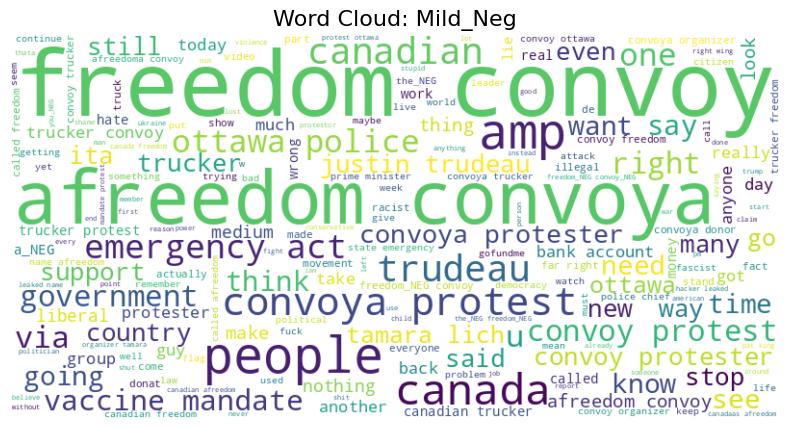

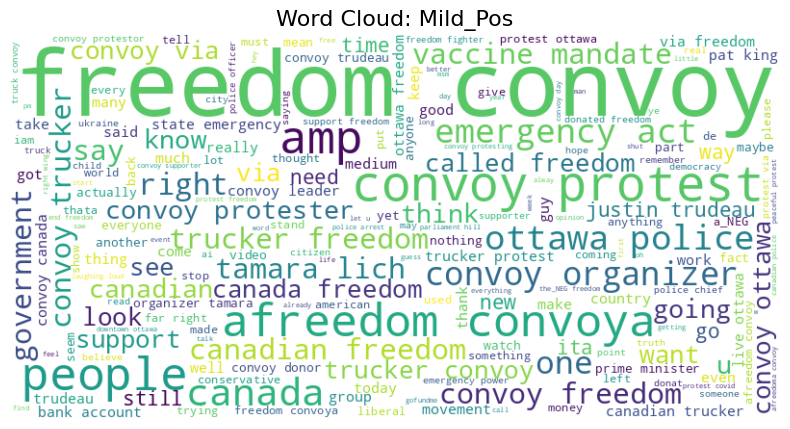

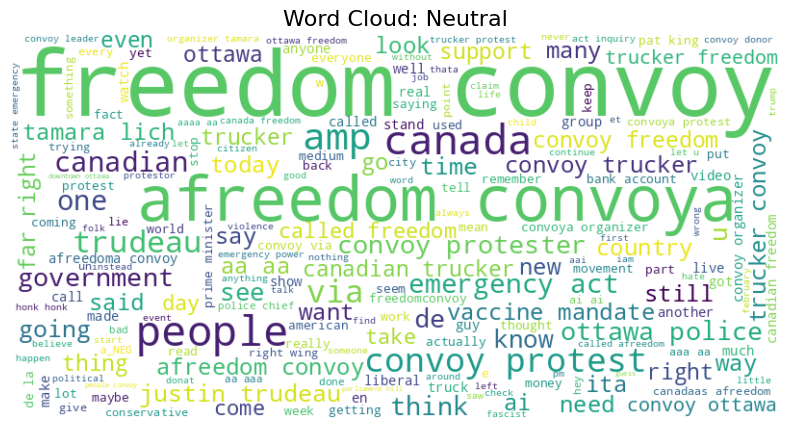

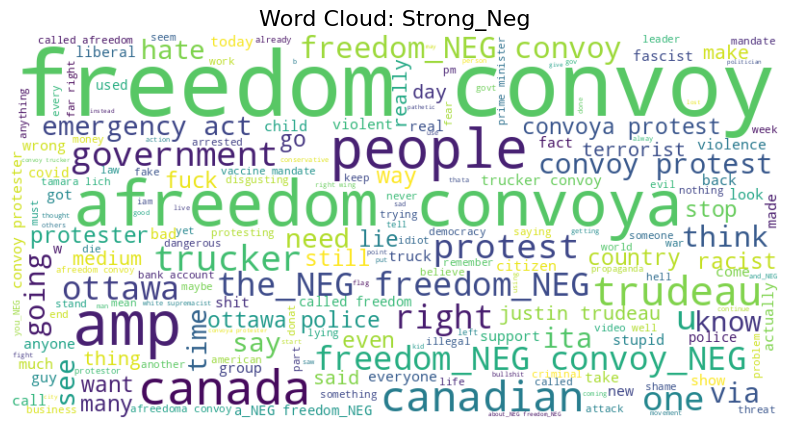

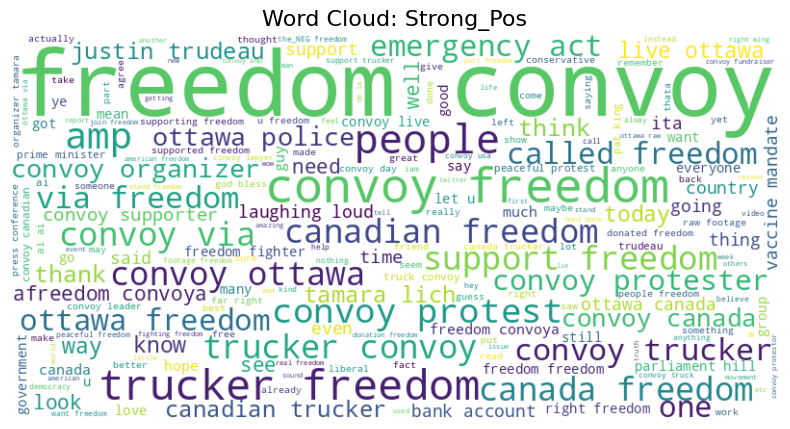

In [180]:
classes = sorted(df['Sentiment'].unique())

img_path = None

for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    if img_path is not None:
        mask = np.array(Image.open(img_path))
    else:
        mask = None
    wc = WordCloud(
        stopwords=STOPWORDS,
        mask=mask,
        background_color="white",
        contour_width=2,
        contour_color="black",
        max_words=200,
        max_font_size=256,
        random_state=42,
        width=800 if mask is None else mask.shape[1],
        height=400 if mask is None else mask.shape[0]
    ).generate(' '.join(map(str, texts.dropna())))
    plt.figure(figsize=(8, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis('off')
    plt.title(f"Word Cloud: {sentiment}", fontsize=16)
    plt.tight_layout()
    plt.show()


### Top 20 most frequent words for all 5 classes

/tmp/ipython-input-181-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


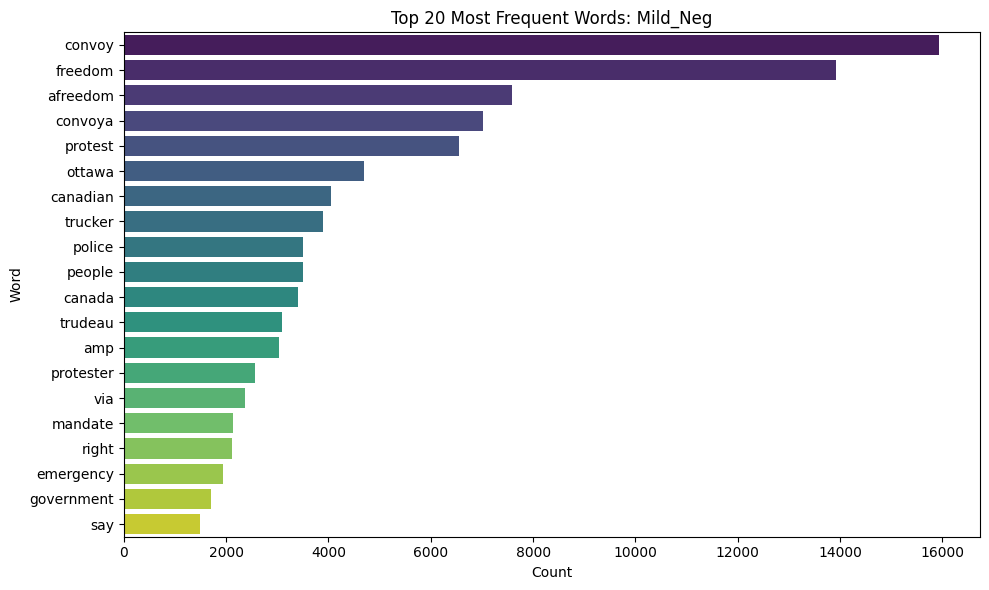

/tmp/ipython-input-181-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


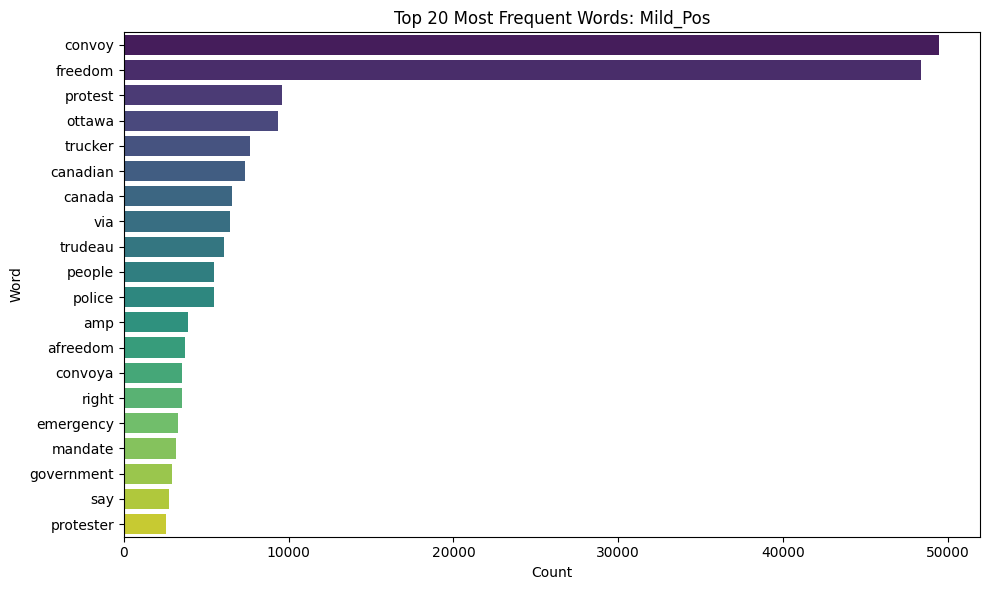

/tmp/ipython-input-181-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


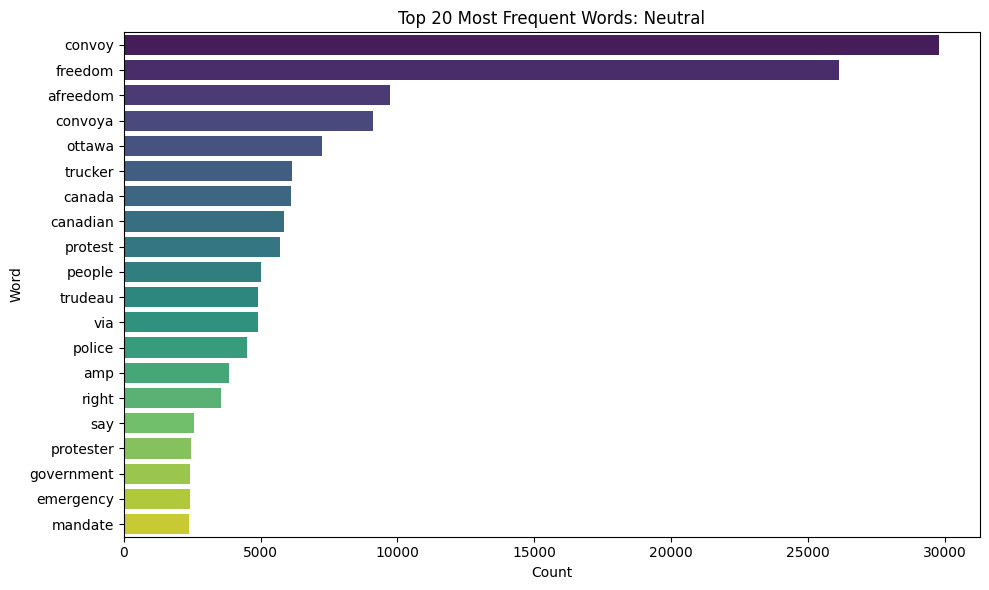

/tmp/ipython-input-181-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


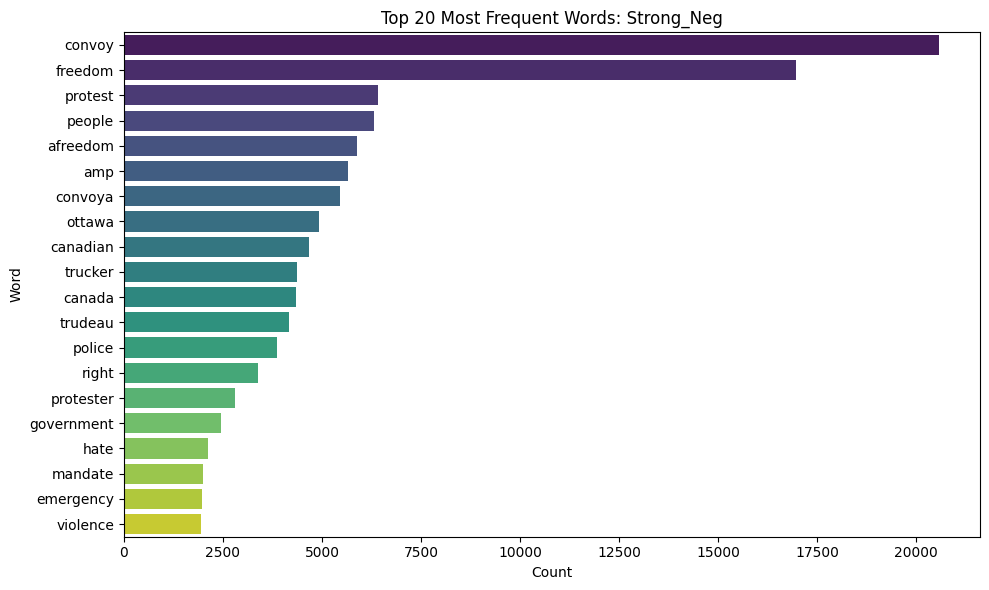

/tmp/ipython-input-181-4107960595.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


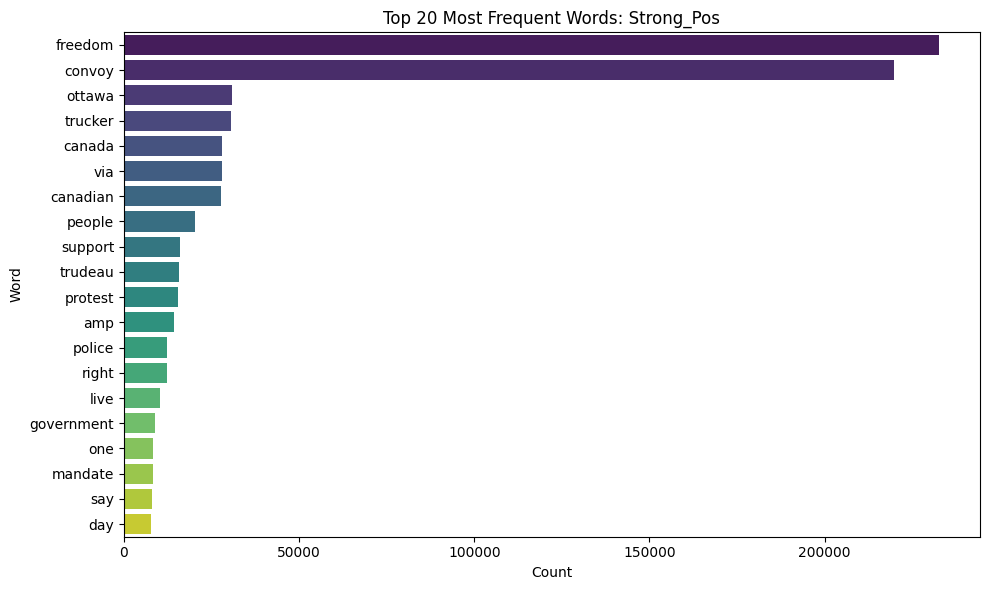

In [181]:
def plot_top_words(texts, n=20, title=None):
    words = [
        word.lower() for text in texts
        for word in word_tokenize(text)
        if word.lower() not in STOPWORDS and len(word) > 2 and word.isalpha()
    ]
    word_counts = Counter(words)
    top_words = word_counts.most_common(n)
    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=[count for word, count in top_words],
        y=[word for word, count in top_words],
        palette='viridis'
    )
    plt.title(title or f'Top {n} Most Frequent Words')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.tight_layout()
    plt.show()

# For all classes
for sentiment in classes:
    texts = df[df['Sentiment'] == sentiment]['clean_tweet']
    plot_top_words(
        texts, n=20, title=f"Top 20 Most Frequent Words: {sentiment}"
    )

# 10. Removing Empty Tweets After Cleaning

In [182]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
empt_str_removed = empt_str
print(f"Total empty strings (after cleaning): {empt_str_removed}")

Total tweets: 451,331
Total empty strings (after cleaning): 10270


## Removing the row from dataframe which has empty string after cleaning the data

In [183]:
df = df[df['clean_tweet'].str.strip().astype(bool)]

In [184]:
total_tweet = len(df)
empt_str = df['clean_tweet'].eq('').sum()
print(f"Total tweets: {total_tweet:,}")
print(f"Total empty strings (after cleaning): {empt_str:,}")

Total tweets: 441,061
Total empty strings (after cleaning): 0


# 11. Consolidating Sentiment Classes

## Mapping original 5 sentiment labels into 3 classes: negative, neutral, positive

In [185]:
def consolidate_label(x):
    if x in ['Mild_Neg', 'Strong_Neg']:
        return 'negative'
    elif x in ['Mild_Pos', 'Strong_Pos']:
        return 'positive'
    else:
        return 'neutral'

df['sentiment_consolidated'] = df['Sentiment'].apply(consolidate_label)


## Plotting distribution after consolidation

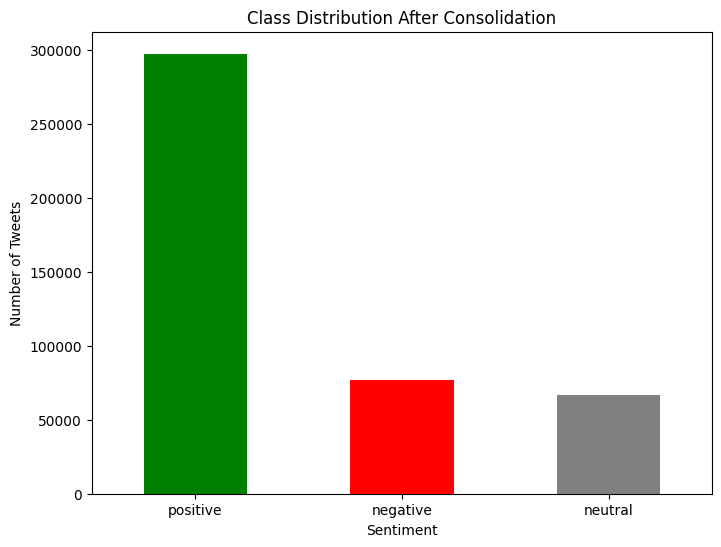

In [186]:
df['sentiment_consolidated'].value_counts().plot(kind='bar', color=['green', 'red', 'grey'])
plt.title('Class Distribution After Consolidation')
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.show()


## Printing counts and proportions

In [187]:
print("Counts:")
print(df['sentiment_consolidated'].value_counts())

print("\nProportions:")
print(df['sentiment_consolidated'].value_counts(normalize=True))


Counts:
sentiment_consolidated
positive    297457
negative     76569
neutral      67035
Name: count, dtype: int64

Proportions:
sentiment_consolidated
positive    0.674412
negative    0.173602
neutral     0.151986
Name: proportion, dtype: float64


There is class imbalance in the dataset as the tweet with sentiment positive are more than the negative and neutral.

# 12. Train / Validation / Test Split
### (before Feature engineering, tf-idf, PCA, Lexicon Score Feature and Label Encoding to avoid Data Leakage)

In [188]:
from sklearn.model_selection import train_test_split

# Step 1: Define inputs
X_full = df[['Tweet', 'clean_tweet']]
y_full = df['sentiment_consolidated']

# Step 2: First split - Separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=42
)

# Step 3: Second split - From remaining, get train (60%) and val (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42
)  # 0.25 x 0.8 = 0.2

# Step 4: Reset indices
X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# ✅ Final Proportions: 60% Train / 20% Val / 20% Test


#13. Feature Engineering: Tweet Length and Hashtag Count


In [189]:
# Feature 1: Tweet Length (based on original tweet text)
X_train['tweet_length'] = X_train['Tweet'].apply(len)
X_val['tweet_length'] = X_val['Tweet'].apply(len)
X_test['tweet_length'] = X_test['Tweet'].apply(len)

# Feature 2: Hashtag Count (using regex)
import re
X_train['num_hashtags'] = X_train['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))
X_val['num_hashtags'] = X_val['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))
X_test['num_hashtags'] = X_test['Tweet'].apply(lambda x: len(re.findall(r"#\w+", str(x))))


#14. TF-IDF Vectorization and PCA Visualization

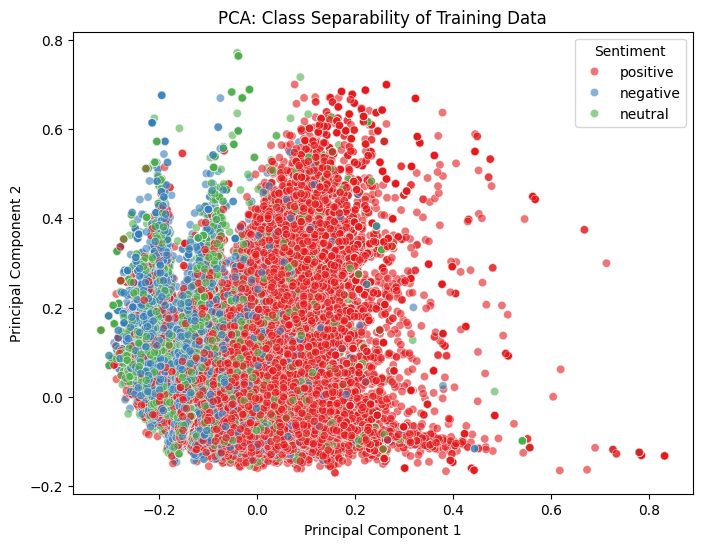

In [190]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Vectorization (fit only on training data)
tf_vectorizer = TfidfVectorizer(max_features=500)
X_train_vec = tf_vectorizer.fit_transform(X_train['clean_tweet'])
X_val_vec   = tf_vectorizer.transform(X_val['clean_tweet'])
X_test_vec  = tf_vectorizer.transform(X_test['clean_tweet'])

# 2. PCA (fit only on training data)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_vec.toarray())
X_val_pca   = pca.transform(X_val_vec.toarray())
X_test_pca  = pca.transform(X_test_vec.toarray())

# 3. Visualize PCA (train set only)
df_pca = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'sentiment': y_train
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='sentiment', palette='Set1', alpha=0.6)
plt.title('PCA: Class Separability of Training Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Sentiment')
plt.show()


#15. Lexicon Score Feature

In [191]:
pos_words = set(opinion_lexicon.positive())
neg_words = set(opinion_lexicon.negative())

In [192]:
def lexicon_score(text, pos_words, neg_words):
    tokens = text.split()
    pos = sum(1 for w in tokens if w in pos_words)
    neg = sum(1 for w in tokens if w in neg_words)
    return pos - neg


In [193]:
# Apply lexicon_score feature to all three sets safely
X_train['lexicon_score'] = X_train['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))
X_val['lexicon_score'] = X_val['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))
X_test['lexicon_score'] = X_test['clean_tweet'].apply(lambda x: lexicon_score(x, pos_words, neg_words))


#16. Label Encoding


In [194]:
# ===============================
# Label Encoding (Post-Split, No Leakage)
# ===============================
from sklearn.preprocessing import LabelEncoder

# Initialize and fit only on training labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded   = label_encoder.transform(y_val)
y_test_encoded  = label_encoder.transform(y_test)

# Optional: to check mapping
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Label Encoding Mapping:", label_mapping)


Label Encoding Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}


In [195]:
label_encoder.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [196]:
df.tail()

,Tweet,Sentiment,word_count,punctuation_count,clean_tweet,emoji_count,slang_count,negation_count,tokens,sentiment_consolidated
451327,"Gaza; Peace n' Freedom - Viva Palestina convoy enters Algeria: \r\nThe Viva Palestina convoy, the massive relief c.. http://tinyurl.com/cajylt",Strong_Pos,19,12,gaza peace freedom viva palestina convoy enters algeria viva palestina convoy massive relief c,0,0,0,"[gaza, peace, freedom, viva, palestina, convoy, enters, algeria, viva, palestina, convoy, massive, relief, c]",positive
451328,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CEN... http://tinyurl.com/dyth62 RT @freerepublic",Strong_Pos,19,14,face defense soldier find freedom fight freedom iraq convoy support cen rt,0,0,0,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, cen, rt]",positive
451329,"Face of Defense: Soldier Finds Freedom in U.S., Fights for Freedom in Iraq: CONVOY SUPPORT CENTER SCANIA, Iraq, .. http://tinyurl.com/dyth62",Strong_Pos,20,14,face defense soldier find freedom fight freedom iraq convoy support center scania iraq,0,0,0,"[face, defense, soldier, find, freedom, fight, freedom, iraq, convoy, support, center, scania, iraq]",positive
451330,"Gaza; Peace n' Freedom - ""Israel stops aid convoy en route to Gaza from Hebron"": \r\nMa&quot;an News Agency report.. http://tinyurl.com/7mguhc",Strong_Pos,20,15,gaza peace freedom israel stop aid convoy en route gaza hebron quot news agency report,0,0,0,"[gaza, peace, freedom, israel, stop, aid, convoy, en, route, gaza, hebron, quot, news, agency, report]",positive
451331,@convoy 83 yes! get on freedom server!,Strong_Pos,7,3,yes get freedom server,0,0,0,"[yes, get, freedom, server]",positive


#17. Exporting Processed Data and Model Artifacts

## Data Preprocessing Checklist

In [201]:
# 1. Regex usage check (approximate by counting regex calls in clean_text)
print("- Regex Cleaning: Applied in clean_text function")

# 2. Emoji Handling
total_emoji = df['emoji_count'].sum() if 'emoji_count' in df.columns else 0
print(f"- Emoji Handling: Done, total emojis handled = {total_emoji}")

# 3. Slang Handling
total_slang = df['slang_count'].sum() if 'slang_count' in df.columns else 0
print(f"- Slang Handling: Done, total slang replacements = {total_slang}")

# 4. Abbreviation Handling (if combined with slang_dict, same as slang_count)
total_abbr = df['abbr_count'].sum() if 'abbr_count' in df.columns else 0
print(f"- Abbreviation Handling: {'Done' if total_abbr>0 else 'Not separated from slang'}, total abbreviations replaced = {total_abbr}")

# 5. Negation Handling
total_negations = df['negation_count'].sum() if 'negation_count' in df.columns else 0
print(f"- Negation Handling: {'Done' if total_negations>0 else 'Not detected'}, total negations tagged = {total_negations}")

# 6. Empty tweets removed
empty_count = df['clean_tweet'].eq('').sum()
print(f"- Empty Tweets Removed: {'Yes, ' + str(empt_str_removed) + ' removed'}, remaining empty tweets = {empty_count}")

# 7. Class distribution after consolidation
if 'sentiment_consolidated' in df.columns:
    print("- Sentiment Classes Distribution:")
    print(df['sentiment_consolidated'].value_counts())
else:
    print("- Sentiment Classes Distribution: Not found")

# 8. Train/Val/Test Split Sizes (if variables exist)
try:
    print(f"- Train size: {len(X_train)}")
    print(f"- Validation size: {len(X_val)}")
    print(f"- Test size: {len(X_test)}")
except NameError:
    print("- Train/Val/Test Split: Variables not found")

# 9. Feature Columns Present (tweet_length, num_hashtags, lexicon_score)
features = ['tweet_length', 'num_hashtags', 'lexicon_score']
for feat in features:
    present = feat in df.columns or ('X_train' in globals() and feat in X_train.columns)
    print(f"- Feature '{feat}': {'Present' if present else 'Missing'}")

print("========================================")


- Regex Cleaning: Applied in clean_text function
- Emoji Handling: Done, total emojis handled = 0
- Slang Handling: Done, total slang replacements = 0
- Abbreviation Handling: Not separated from slang, total abbreviations replaced = 0
- Negation Handling: Done, total negations tagged = 330955
- Empty Tweets Removed: Yes, 10270 removed, remaining empty tweets = 0
- Sentiment Classes Distribution:
sentiment_consolidated
positive    297457
negative     76569
neutral      67035
Name: count, dtype: int64
- Train size: 264636
- Validation size: 88212
- Test size: 88213
- Feature 'tweet_length': Present
- Feature 'num_hashtags': Present
- Feature 'lexicon_score': Present


## Exporting train, val, test sets (features and labels) as CSV

In [198]:
import os

os.makedirs('../data/processed', exist_ok=True)

X_train.to_csv('X_train.csv', index=False)
X_val.to_csv('X_val.csv', index=False)
X_test.to_csv('X_test.csv', index=False)

y_train.to_frame().to_csv('y_train.csv', index=False)
y_val.to_frame().to_csv('y_val.csv', index=False)
y_test.to_frame().to_csv('y_test.csv', index=False)

## Exporting the label encoder

In [202]:
import pickle
with open('label_encoder1.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)